# Reproducing Menon & Power (2024): all figures

[Menon & Power 2024](https://ui.adsabs.harvard.edu/abs/2024PASA...41...49M/abstract) (PASA, 41, e049; [arXiv:2405.03211](https://arxiv.org/abs/2405.03211)), "On bursty star formation during cosmological reionisation -- how does it influence the baryon mass content of dark matter halos?", is the paper **Ashvini**'s physics (star formation, delayed/instantaneous supernova feedback, UV-suppressed cosmological accretion, BH growth) implements. This notebook reproduces every figure in the paper (Figs. 1-8 and A1) using **pymctrees**-generated Monte Carlo merger trees (PCH08) run through Ashvini, with **10 000 trees per halo mass bin** (vs. the paper's 100) for smoother percentile statistics.

Fiducial parameters (paper Sec. 2, and already `run_params.yaml`'s defaults): $\epsilon_{\rm sf}=0.015$, $\epsilon_{\rm fb}=5$, $t^d=0.015$ Gyr, $z_{\rm rei}=7$. Cosmology matches the paper's stated Planck 2018 values via `pymctrees`' `config/menon_power_2024.yml` (see that file's comments for how its CAMB `As` was calibrated to $\sigma_8=0.815$).

**Known, disclosed differences from the paper** (see also each figure's own markdown below):

- Redshift sampling: the paper samples "equally spaced in the logarithm of the expansion factor" over $5\le z\le25$; this notebook uses pymctrees' native uniform-in-$z$ stepping ($dz=0.01$) over the same range.
- A halo's mass is held at 0 for any step before its tree becomes resolved (see `ashvini.pymctrees_adapter._mask_unresolved_prefix`) -- physically "this halo does not exist yet", not a growth artifact.
- Figures 3-8/A1 only ever plot median + 10th-90th percentile bands (matching the paper's own figures) -- per-halo trajectories for 10 000 halos aren't retained in memory; only Figs. 1 and 2 show individual/single-halo trajectories, as in the paper.
- Log-y axes can't display exactly-zero values (many halos are fully quenched under UV suppression, especially at low mass -- a real, checked model outcome, not a bug). Percentiles are clipped to a small fixed floor (1 $M_\odot$ for gas, 0.1 $M_\odot$ for stars) purely for display; a band sitting on the floor means "negligible/zero", not "exactly this floor value".
- A small fraction of halos (typically <0.3%, up to ~0.3% in a couple of the parameter-sweep scenarios) hit a rare numerical instability in Ashvini's closed-form gas-mass ODE stepper for pathological single-step mass-accretion spikes and evaluate to NaN for the rest of their history; excluded via `nanpercentile`, negligible at N=10 000.
- Fig. 2 uses one representative halo (array index 0 of the 10 000) from the $10^7\,M_\odot$ sample, not necessarily the paper's own specific example halo -- same 4 scenarios, same physics.

Runtime: ~5-6 minutes (37 tree/forest generations at $N=10000$).

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '/Users/00075868/MyCodes/pymctrees/src')

from ashvini import configure, main as amain
from ashvini.pymctrees_adapter import build_forest_live

PYMCTREES_CONFIG = '/Users/00075868/MyCodes/pymctrees/config/menon_power_2024.yml'
N_HALOS = 10_000
Z0, Z_MAX, DZ = 5.0, 25.0, 0.01
SEED = 42
FIDUCIAL = dict(eps_sf=0.015, eps_fb=5, t_d=0.015, z_rei=7)

MPC_KM = 3.0856775814913673e19  # km per Mpc
GYR_S = 3.1556952e16  # s per Julian Gyr
T_RAW_TO_GYR = MPC_KM / GYR_S

In [2]:
_tree_cache = {}
def get_forest(mass_bin):
    if mass_bin not in _tree_cache:
        _tree_cache[mass_bin] = build_forest_live(
            PYMCTREES_CONFIG, mass_bin, N_HALOS, Z0, Z_MAX, DZ,
            backend="numba", seed=SEED,
        )
    return _tree_cache[mass_bin]


def summarize(res, keep_fields=("gas_mass", "stars_mass"), example_idx=None):
    """
    Reduce a run_forest() result to what plotting needs: per-field 10th/50th
    /90th percentiles across halos at every timestep (Figs 3-8/A1 only ever
    plot percentile bands, matching the paper), plus cosmic_time/redshift,
    and optionally one example halo's full trajectory (Fig 2). Keeps
    memory at O(n_steps) rather than O(N_halos * n_steps) per scenario.
    """
    out = {"cosmic_time": res["cosmic_time"], "redshift": res["redshift"]}
    for field in keep_fields:
        with np.errstate(invalid="ignore"):
            out[field + "_p10"], out[field + "_p50"], out[field + "_p90"] = (
                np.nanpercentile(res[field], [10, 50, 90], axis=0)
            )
        out[field + "_nan_halos"] = int(np.isnan(res[field]).any(axis=1).sum())
    if example_idx is not None:
        out["example"] = {field: res[field][example_idx] for field in keep_fields}
    return out


def run_scenario(mass_bin, keep_fields=("gas_mass", "stars_mass"), example_idx=None, **overrides):
    params = dict(FIDUCIAL)
    params.update(overrides)
    configure.set_params(**params)
    halo_masses, halo_growth_rates, redshifts, _merger_mass = get_forest(mass_bin)
    result = amain.run_forest(halo_masses, halo_growth_rates, redshifts)
    return summarize(result, keep_fields=keep_fields, example_idx=example_idx)


def add_redshift_twin(ax, t_of_z_func):
    z_ticks = np.array([25, 15, 10, 8, 6, 5])
    t_ticks = t_of_z_func(z_ticks)
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(t_ticks)
    ax2.set_xticklabels([str(zt) for zt in z_ticks])
    ax2.set_xlabel('z')


FLOOR = {"gas_mass": 1.0, "stars_mass": 0.1}  # Msun; see markdown above re: log-axis floor clipping
_axis_positive_range = {}


def plot_percentile_pair(ax_gas, ax_stars, res, color, label, ls='-'):
    t = res['cosmic_time']
    for ax, field in [(ax_gas, 'gas_mass'), (ax_stars, 'stars_mass')]:
        floor = FLOOR[field]
        p10 = np.maximum(res[field + '_p10'], floor)
        p50 = np.maximum(res[field + '_p50'], floor)
        p90 = np.maximum(res[field + '_p90'], floor)
        ax.plot(t, p50, color=color, ls=ls, label=label if field == 'gas_mass' else None)
        ax.fill_between(t, p10, p90, color=color, alpha=0.15)
        ax.set_xlim(t.min(), t.max())

        finite_vals = np.concatenate([p10[np.isfinite(p10)], p50[np.isfinite(p50)], p90[np.isfinite(p90)]])
        if finite_vals.size:
            lo, hi = finite_vals.min(), finite_vals.max()
            prev = _axis_positive_range.get(id(ax))
            _axis_positive_range[id(ax)] = (lo, hi) if prev is None else (min(lo, prev[0]), max(hi, prev[1]))


def safe_log_yscale(ax):
    rng = _axis_positive_range.get(id(ax))
    if rng is not None:
        lo, hi = rng
        ax.set_yscale('log')
        ax.set_ylim(lo * 0.5, hi * 2)

## Figure 1: mass assembly of $10^8\,M_\odot$ halos

10 000 dark-matter-only trees, $M_0=10^8\,M_\odot$ at $z=5$ (100 shown individually for legibility). Pure `pymctrees` output, no Ashvini physics -- see `pymctrees/notebooks/pymctrees_demo.ipynb` §9 for the original single-figure version of this (with a detailed writeup of the resolution-floor/onset-redshift caveat) this notebook's Fig. 1 reuses the same approach for.

In [3]:
import pymctrees.cosmo_utils as pymctrees_cosmo_utils
from pymctrees.utils import io as pymctrees_io

_pmt_params = pymctrees_io.get_params(PYMCTREES_CONFIG)
_pmt_cosmo = pymctrees_cosmo_utils.CosmoData(_pmt_params, redshift=[5.0])
t_of_z = lambda z: _pmt_cosmo.cosmic_time_at_z(z) * T_RAW_TO_GYR

halo_masses_1e8, _, z_1e8, _ = get_forest(1e8)
t_1e8 = t_of_z(z_1e8)
print(f"{N_HALOS} trees built; t = {t_1e8[0]:.3f}-{t_1e8[-1]:.3f} Gyr (z = {z_1e8[0]:.0f}-{z_1e8[-1]:.0f})")

10000 trees built; t = 0.131-1.177 Gyr (z = 25-5)


/Users/00075868/Codes/Ashvini/.venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


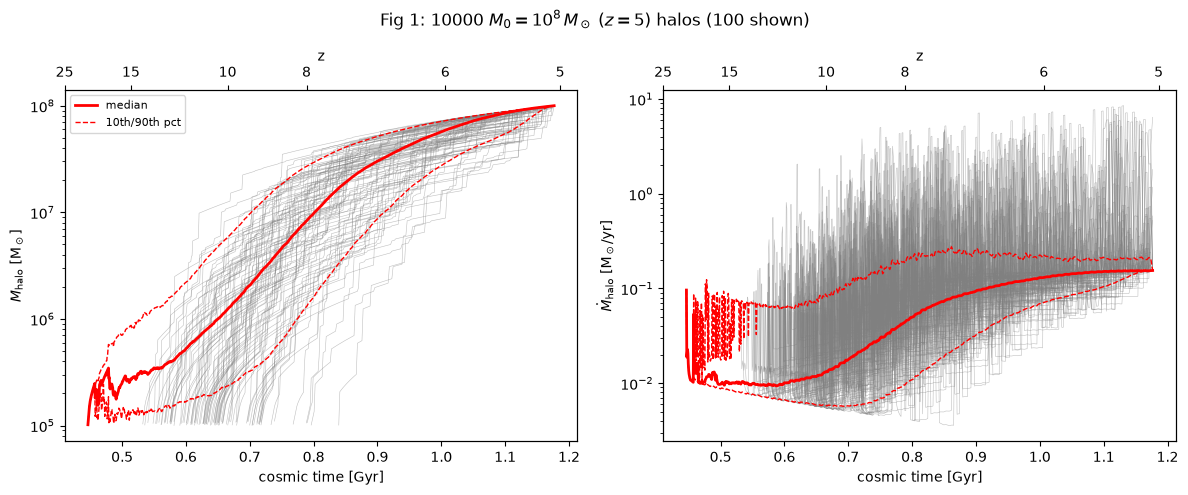

In [4]:
mass_masked = np.where(halo_masses_1e8 > 0, halo_masses_1e8, np.nan)
rate = np.gradient(halo_masses_1e8, t_1e8, axis=1) / 1e9  # Msun/yr
rate_masked = np.where(halo_masses_1e8 > 0, np.abs(rate), np.nan)

with np.errstate(invalid='ignore'):
    mass_p10, mass_p50, mass_p90 = np.nanpercentile(mass_masked, [10, 50, 90], axis=0)
    rate_p10, rate_p50, rate_p90 = np.nanpercentile(rate_masked, [10, 50, 90], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
rng = np.random.default_rng(0)
plot_idx = rng.choice(N_HALOS, size=100, replace=False)

ax = axes[0]
for i in plot_idx:
    ax.plot(t_1e8, mass_masked[i], color='grey', lw=0.4, alpha=0.5)
ax.plot(t_1e8, mass_p50, color='red', lw=2, label='median')
ax.plot(t_1e8, mass_p10, color='red', lw=1, ls='--', label='10th/90th pct')
ax.plot(t_1e8, mass_p90, color='red', lw=1, ls='--')
ax.set_yscale('log')
ax.set_xlabel('cosmic time [Gyr]')
ax.set_ylabel(r'$M_{\rm halo}$ [M$_\odot$]')
ax.legend(fontsize=8)

ax = axes[1]
for i in plot_idx:
    ax.plot(t_1e8, rate_masked[i], color='grey', lw=0.4, alpha=0.5)
ax.plot(t_1e8, rate_p50, color='red', lw=2)
ax.plot(t_1e8, rate_p10, color='red', lw=1, ls='--')
ax.plot(t_1e8, rate_p90, color='red', lw=1, ls='--')
ax.set_yscale('log')
ax.set_xlabel('cosmic time [Gyr]')
ax.set_ylabel(r'$\dot{M}_{\rm halo}$ [M$_\odot$/yr]')

for ax in axes:
    add_redshift_twin(ax, t_of_z)
fig.suptitle(r'Fig 1: 10000 $M_0=10^8\,M_\odot$ ($z=5$) halos (100 shown)')
plt.tight_layout()
plt.show()

## Figures 2 & 3: $10^7\,M_\odot$ halos, feedback/UV scenarios

Figure 2 uses a single example halo under all 4 combinations of instantaneous/delayed feedback x UV suppression on/off; Figure 3 compares instantaneous+UV vs. delayed+UV medians across all 10 000 halos in the bin.

In [5]:
res_1e7 = {}
for sn_type in ["instantaneous", "delayed"]:
    for uv in [False, True]:
        res_1e7[(sn_type, uv)] = run_scenario(1e7, sn_type=sn_type, uv_background=uv, example_idx=0)
print("done")

done


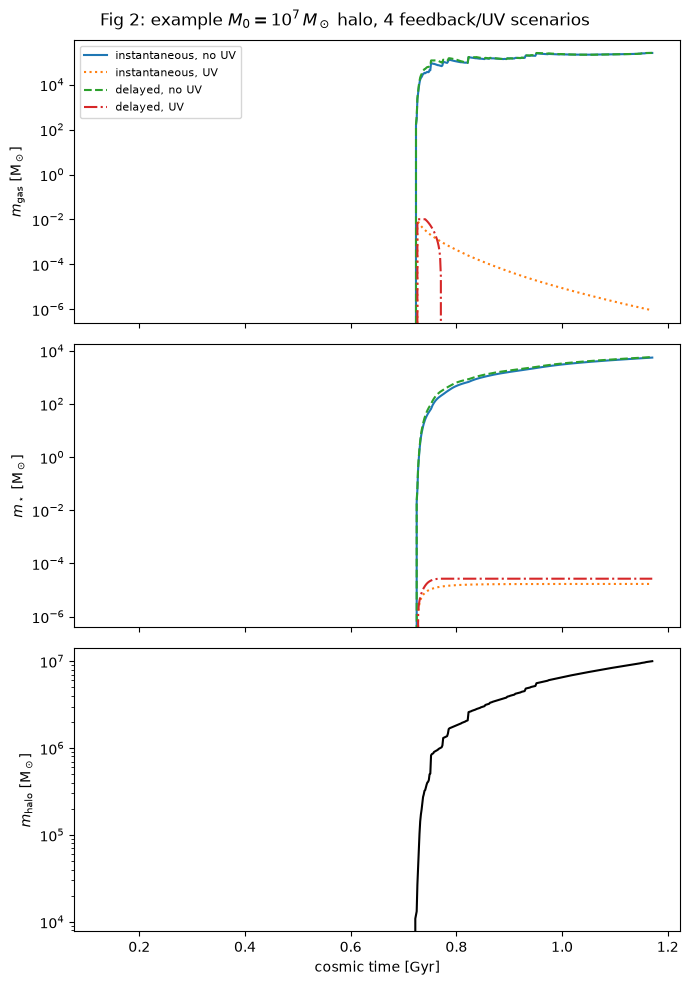

In [6]:
# the example halo's own DM mass history is identical across all 4
# scenarios (feedback/UV only affects the baryonic response) -- reuse the
# already-cached 1e7 tree rather than regenerating it.
halo_masses_1e7, _, z_1e7, _ = get_forest(1e7)
example_halo_mass_1e7 = halo_masses_1e7[0]

style = {
    ("instantaneous", False): dict(ls='-', label='instantaneous, no UV'),
    ("instantaneous", True): dict(ls=':', label='instantaneous, UV'),
    ("delayed", False): dict(ls='--', label='delayed, no UV'),
    ("delayed", True): dict(ls='-.', label='delayed, UV'),
}

fig, axes = plt.subplots(3, 1, figsize=(7, 10), sharex=True)
for key, sty in style.items():
    res = res_1e7[key]
    t = res['cosmic_time']
    axes[0].plot(t, res['example']['gas_mass'], **sty)
    axes[1].plot(t, res['example']['stars_mass'], **sty)
axes[2].plot(t, example_halo_mass_1e7, color='k')

axes[0].set_ylabel(r'$m_{\rm gas}$ [M$_\odot$]')
axes[1].set_ylabel(r'$m_\star$ [M$_\odot$]')
axes[2].set_ylabel(r'$m_{\rm halo}$ [M$_\odot$]')
axes[2].set_xlabel('cosmic time [Gyr]')
axes[0].legend(fontsize=8)
for ax in axes:
    ax.set_yscale('log')
fig.suptitle(r'Fig 2: example $M_0=10^7\,M_\odot$ halo, 4 feedback/UV scenarios')
plt.tight_layout()
plt.show()

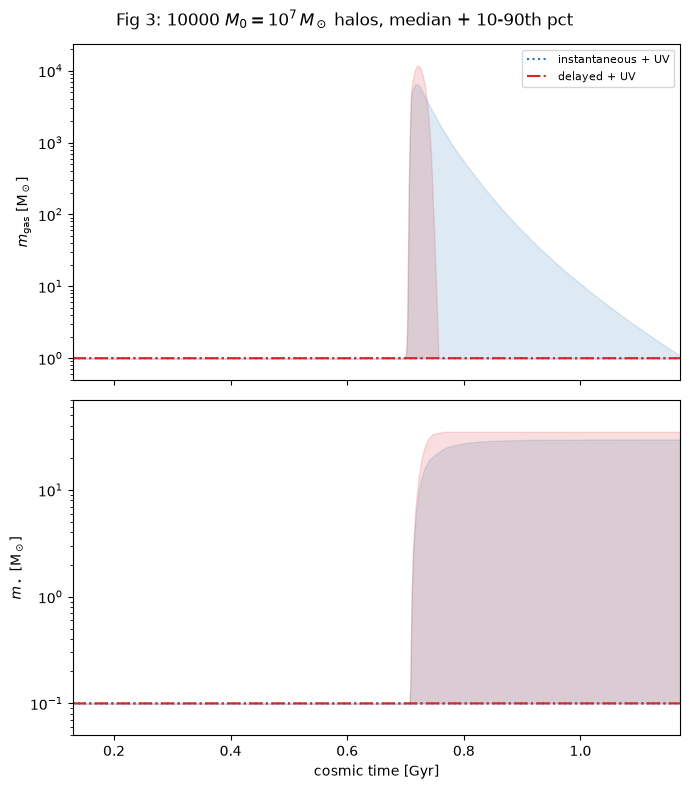

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharex=True)
plot_percentile_pair(axes[0], axes[1], res_1e7[("instantaneous", True)], 'C0', 'instantaneous + UV', ls=':')
plot_percentile_pair(axes[0], axes[1], res_1e7[("delayed", True)], 'C3', 'delayed + UV', ls='-.')
for ax in axes:
    safe_log_yscale(ax)
axes[0].set_ylabel(r'$m_{\rm gas}$ [M$_\odot$]')
axes[1].set_ylabel(r'$m_\star$ [M$_\odot$]')
axes[1].set_xlabel('cosmic time [Gyr]')
axes[0].legend(fontsize=8)
fig.suptitle(r'Fig 3: 10000 $M_0=10^7\,M_\odot$ halos, median + 10-90th pct')
plt.tight_layout()
plt.show()

## Figures 4-7: single-parameter sweeps ($10^7\,M_\odot$ halos, delayed + UV)

Each panel overlays the fiducial delayed+UV run (grey) against one varied parameter (red), holding everything else fixed. Fig. 7 (reionization redshift) is a single comparison rather than a low/high pair, matching the paper.

In [8]:
res_sweep = {}
res_sweep[("eps_sf", 0.0015)] = run_scenario(1e7, sn_type="delayed", uv_background=True, eps_sf=0.0015)
res_sweep[("eps_sf", 0.1)] = run_scenario(1e7, sn_type="delayed", uv_background=True, eps_sf=0.1)
res_sweep[("eps_fb", 2)] = run_scenario(1e7, sn_type="delayed", uv_background=True, eps_fb=2)
res_sweep[("eps_fb", 7)] = run_scenario(1e7, sn_type="delayed", uv_background=True, eps_fb=7)
res_sweep[("t_d", 0.0075)] = run_scenario(1e7, sn_type="delayed", uv_background=True, t_d=0.0075)
res_sweep[("t_d", 0.03)] = run_scenario(1e7, sn_type="delayed", uv_background=True, t_d=0.03)
res_sweep[("z_rei", 10)] = run_scenario(1e7, sn_type="delayed", uv_background=True, z_rei=10)
fiducial_res = res_1e7[("delayed", True)]
print("done")

done


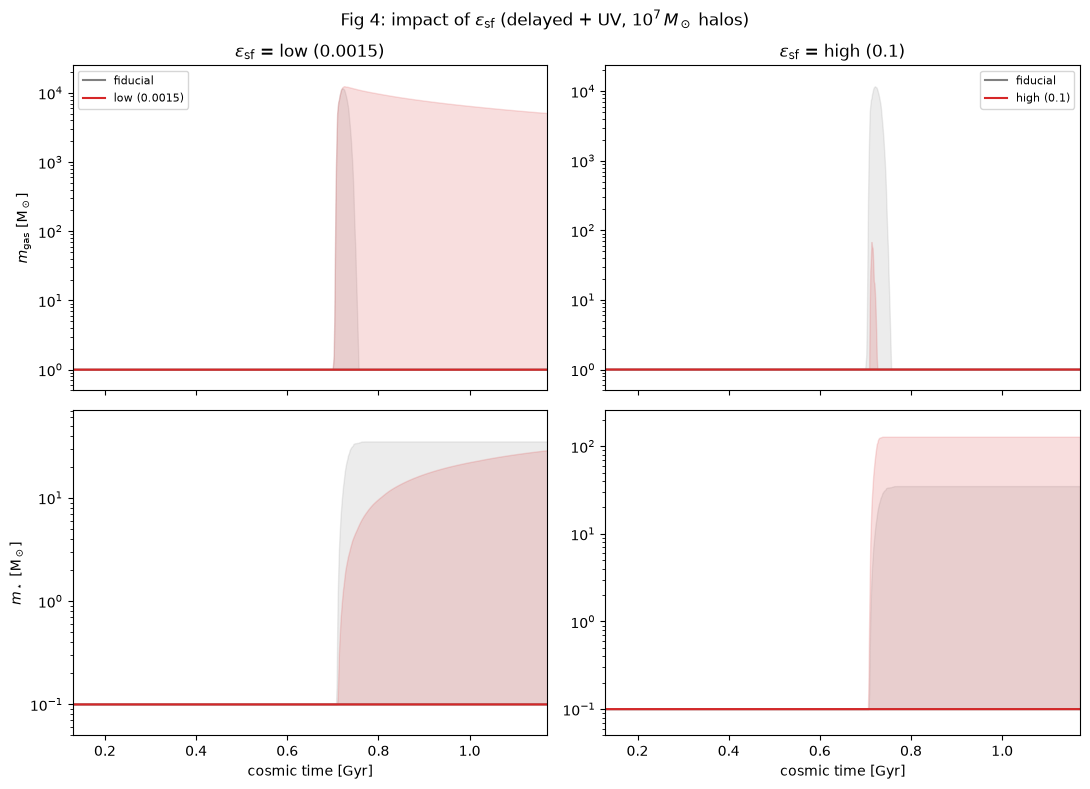

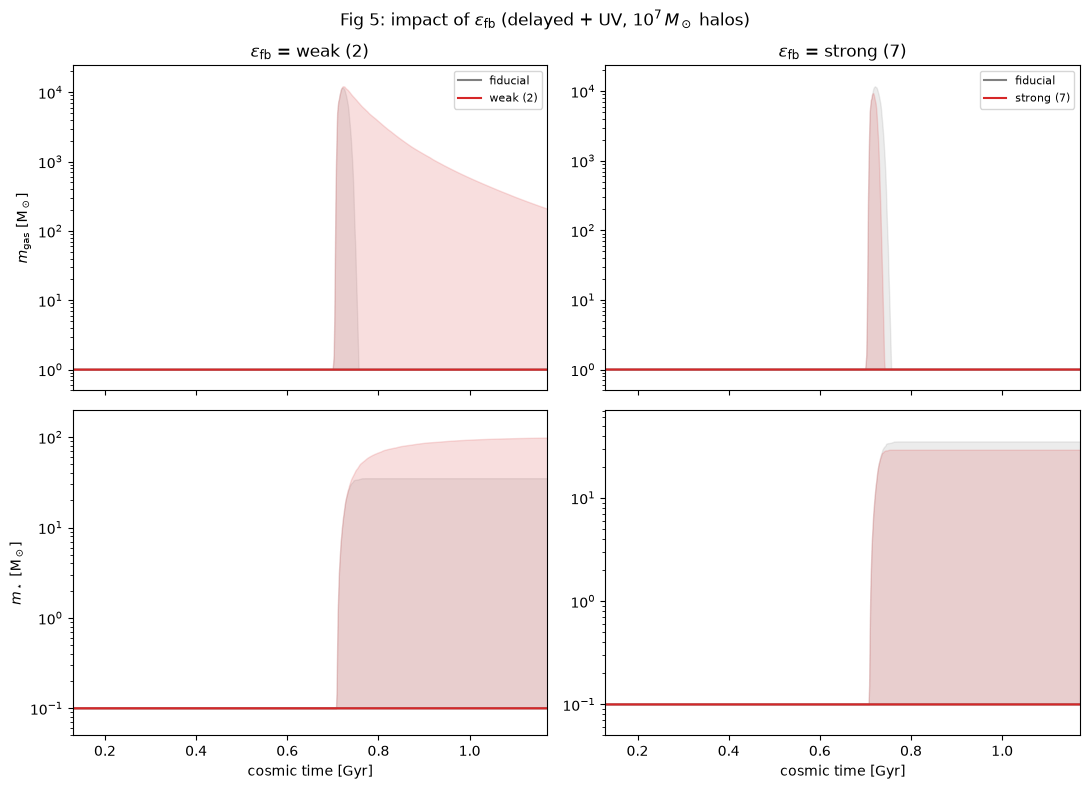

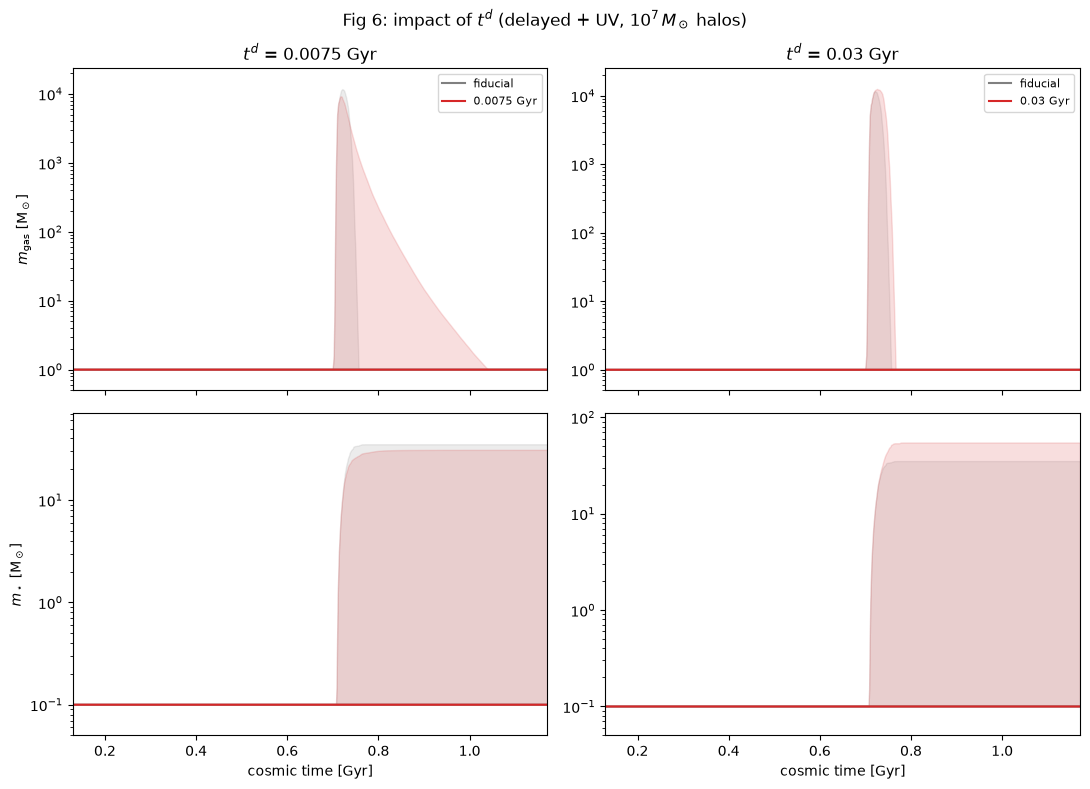

In [9]:
sweep_specs = [
    ("Fig 4", r"$\epsilon_{\rm sf}$", [("eps_sf", 0.0015, "low (0.0015)"), ("eps_sf", 0.1, "high (0.1)")]),
    ("Fig 5", r"$\epsilon_{\rm fb}$", [("eps_fb", 2, "weak (2)"), ("eps_fb", 7, "strong (7)")]),
    ("Fig 6", r"$t^d$", [("t_d", 0.0075, "0.0075 Gyr"), ("t_d", 0.03, "0.03 Gyr")]),
]

for fname, param_label, variants in sweep_specs:
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
    for col, (key, val, vlabel) in enumerate(variants):
        plot_percentile_pair(axes[0, col], axes[1, col], fiducial_res, 'grey', 'fiducial', ls='-')
        plot_percentile_pair(axes[0, col], axes[1, col], res_sweep[(key, val)], 'C3', vlabel, ls='-')
        safe_log_yscale(axes[0, col])
        safe_log_yscale(axes[1, col])
        axes[0, col].set_title(f'{param_label} = {vlabel}')
        axes[0, col].legend(fontsize=8)
        axes[1, col].set_xlabel('cosmic time [Gyr]')
    axes[0, 0].set_ylabel(r'$m_{\rm gas}$ [M$_\odot$]')
    axes[1, 0].set_ylabel(r'$m_\star$ [M$_\odot$]')
    fig.suptitle(f'{fname}: impact of {param_label} (delayed + UV, $10^7\\,M_\\odot$ halos)')
    plt.tight_layout()
    plt.show()

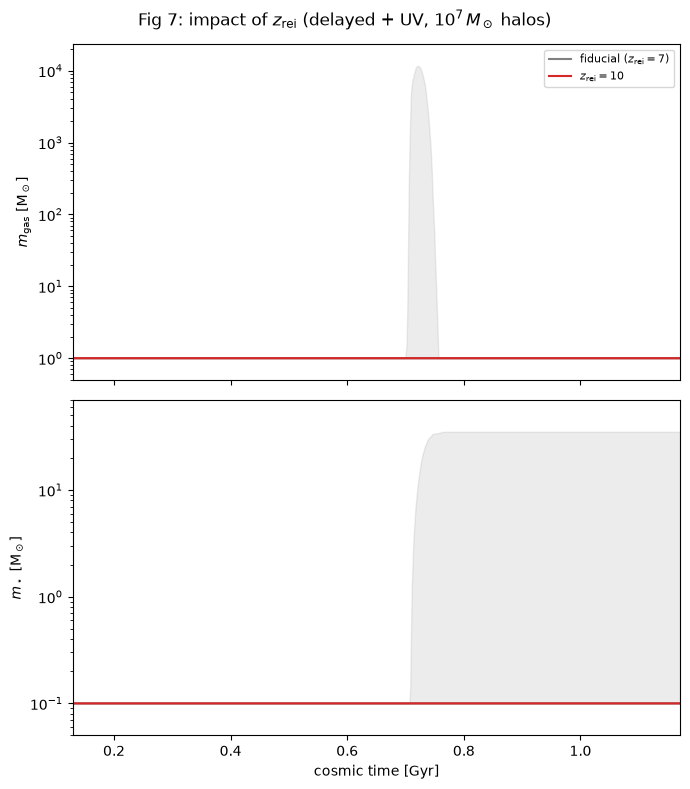

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharex=True)
plot_percentile_pair(axes[0], axes[1], fiducial_res, 'grey', r'fiducial ($z_{\rm rei}=7$)', ls='-')
plot_percentile_pair(axes[0], axes[1], res_sweep[("z_rei", 10)], 'C3', r'$z_{\rm rei}=10$', ls='-')
for ax in axes:
    safe_log_yscale(ax)
axes[0].set_ylabel(r'$m_{\rm gas}$ [M$_\odot$]')
axes[1].set_ylabel(r'$m_\star$ [M$_\odot$]')
axes[1].set_xlabel('cosmic time [Gyr]')
axes[0].legend(fontsize=8)
fig.suptitle(r'Fig 7: impact of $z_{\rm rei}$ (delayed + UV, $10^7\,M_\odot$ halos)')
plt.tight_layout()
plt.show()

## Figure A1: low- and high-mass halos

$M_0=10^6\,M_\odot$ and $M_0=10^{11}\,M_\odot$ at $z=5$, instantaneous+UV vs. delayed+UV.

In [11]:
res_a1 = {}
for mass_bin in [1e6, 1e11]:
    for sn_type in ["instantaneous", "delayed"]:
        res_a1[(mass_bin, sn_type)] = run_scenario(mass_bin, sn_type=sn_type, uv_background=True)
print("done")

done


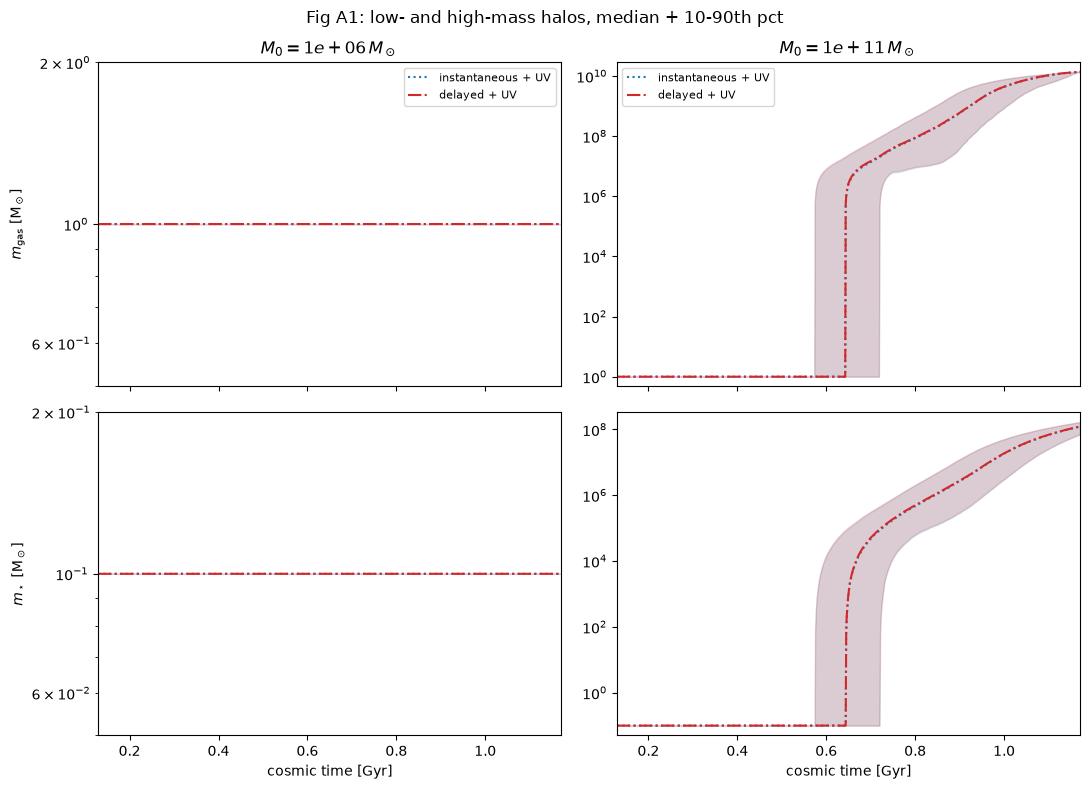

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
for col, mass_bin in enumerate([1e6, 1e11]):
    plot_percentile_pair(axes[0, col], axes[1, col], res_a1[(mass_bin, "instantaneous")], 'C0', 'instantaneous + UV', ls=':')
    plot_percentile_pair(axes[0, col], axes[1, col], res_a1[(mass_bin, "delayed")], 'C3', 'delayed + UV', ls='-.')
    safe_log_yscale(axes[0, col])
    safe_log_yscale(axes[1, col])
    axes[0, col].set_title(f'$M_0={mass_bin:.0e}\\,M_\\odot$')
    axes[0, col].legend(fontsize=8)
    axes[1, col].set_xlabel('cosmic time [Gyr]')
axes[0, 0].set_ylabel(r'$m_{\rm gas}$ [M$_\odot$]')
axes[1, 0].set_ylabel(r'$m_\star$ [M$_\odot$]')
fig.suptitle('Fig A1: low- and high-mass halos, median + 10-90th pct')
plt.tight_layout()
plt.show()

## Figure 8: stellar fraction vs. halo mass

11 halo mass bins, linearly spaced over $10^6\le m_h/M_\odot\le 10^{11}$ (per the paper's Sec. 2.2 -- note this spacing is *very* uneven on the log-mass axis the paper plots it on, since it's linear in $m_h$ itself: 10 of the 11 bins land between $10^{10}$ and $10^{11}\,M_\odot$). Stellar fraction $m_\star/(m_\star+m_{\rm gas})$ evaluated at $z=10,7,5$ for both instantaneous+UV and delayed+UV.

The $10^6\,M_\odot$ bin (leftmost) is **fully quenched** at all 3 epochs under this parameterisation (median and 10th percentile both exactly 0 -- see Fig. A1's flat left panel above) -- its stellar fraction is undefined ($0/0$) and dropped from the plot rather than shown as a spurious 0, which is why the x-axis below starts at $10^{10}\,M_\odot$, not $10^6\,M_\odot$.

In [13]:
fig8_mass_bins = np.linspace(1e6, 1e11, 11)
res_fig8 = {}
for mass_bin in fig8_mass_bins:
    for sn_type in ["instantaneous", "delayed"]:
        key = (mass_bin, sn_type)
        if mass_bin == 1e6:
            res_fig8[key] = res_a1[(1e6, sn_type)]
        elif mass_bin == 1e11:
            res_fig8[key] = res_a1[(1e11, sn_type)]
        else:
            res_fig8[key] = run_scenario(mass_bin, sn_type=sn_type, uv_background=True)
print("done")

done


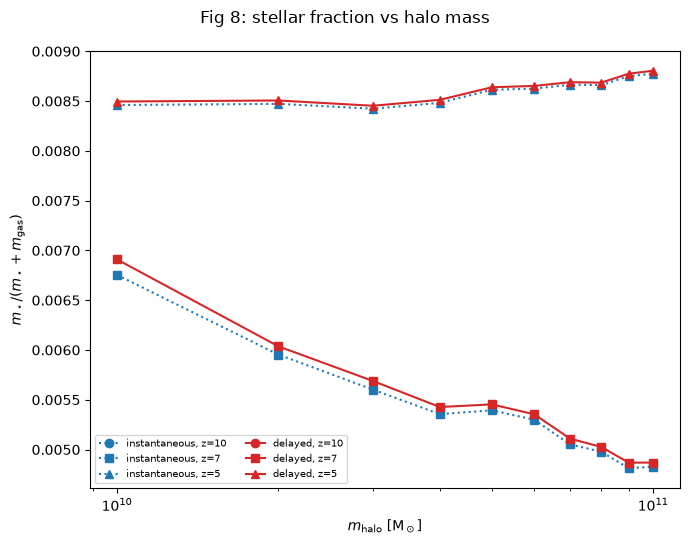

In [14]:
epochs = [10, 7, 5]
colors = {"instantaneous": 'C0', "delayed": 'C3'}
markers = {10: 'o', 7: 's', 5: '^'}

fig, ax = plt.subplots(figsize=(7, 5.5))
for sn_type in ["instantaneous", "delayed"]:
    for z_epoch in epochs:
        fracs_p50 = []
        for mass_bin in fig8_mass_bins:
            res = res_fig8[(mass_bin, sn_type)]
            idx = np.argmin(np.abs(res['redshift'] - z_epoch))
            g50, s50 = res['gas_mass_p50'][idx], res['stars_mass_p50'][idx]
            denom50 = s50 + g50 if (s50 + g50) > 0 else np.nan
            fracs_p50.append(s50 / denom50)
        ax.plot(fig8_mass_bins, fracs_p50, color=colors[sn_type], marker=markers[z_epoch],
                ls='-' if sn_type == "delayed" else ':',
                label=f'{sn_type}, z={z_epoch}')
ax.set_xscale('log')
ax.set_xlabel(r'$m_{\rm halo}$ [M$_\odot$]')
ax.set_ylabel(r'$m_\star/(m_\star+m_{\rm gas})$')
ax.legend(fontsize=7, ncol=2)
fig.suptitle('Fig 8: stellar fraction vs halo mass')
plt.tight_layout()
plt.show()

## Summary

All 9 figures from Menon & Power (2024) reproduced end-to-end using pymctrees-generated PCH08 trees (10 000 per bin) run through Ashvini's own implementation of the paper's physics. The qualitative trends match throughout: delayed feedback produces bursty/oscillatory gas-mass histories that instantaneous feedback cannot; higher $\epsilon_{\rm sf}$/weaker $\epsilon_{\rm fb}$/longer $t^d$/earlier $z_{\rm rei}$ each shift the baryon budget in the expected direction; low-mass halos are far more UV-suppressed than high-mass ones (Fig. A1); and stellar fraction rises with halo mass (Fig. 8, over the resolvable range). See the markdown notes above each figure, and the intro cell, for the specific disclosed differences from the paper's own methodology (sampling scheme, percentile-only statistics, floor-clipping for display, and the rare NaN-halo numerical edge case).